# 🥇 Implementando a Camada Layer

## 👨‍💻 Criação da Tabela Fato (SQL)

In [0]:
%sql
-- Criando a visão consolidada para o Dashboard
CREATE OR REPLACE TABLE gold_vendas_papelaria AS
SELECT 
    p.id_pedido,
    p.data_pedido,
    c.nome AS cliente,
    c.estado,
    pr.nome AS produto,
    pr.categoria,
    ip.quantidade,
    ip.preco_unit,
    ip.subtotal AS faturamento
FROM silver_pedidos p
INNER JOIN silver_clientes c ON p.id_cliente = c.id_cliente
INNER JOIN silver_itens_pedido ip ON p.id_pedido = ip.id_pedido
INNER JOIN silver_produtos pr ON ip.id_produto = pr.id_produto;

num_affected_rows,num_inserted_rows


In [0]:
%sql
-- Verificando os primeiros 10 registros da tabela Gold
SELECT * FROM gold_vendas_papelaria LIMIT 10;

id_pedido,data_pedido,cliente,estado,produto,categoria,quantidade,preco_unit,faturamento
22,2023-01-01T00:00:00.000Z,Ana Silva,SP,Lápis de cores 12 cores,Escolar,1,5.0,5.0
20,2024-03-25T00:00:00.000Z,Diego Lima,PR,Marcador de texto Amarelo,Escrita,4,4.8,19.2
3,2023-03-05T00:00:00.000Z,Carla Souza,MG,Caderno brochura,Papelaria,1,12.0,12.0
18,2024-03-10T00:00:00.000Z,Bruno Costa,RJ,Caderno de caligrafia,Escolar,5,9.5,47.5
1,2023-01-20T00:00:00.000Z,Ana Silva,SP,Caneta Vermelha,Escrita,1,2.5,2.5
13,2024-01-10T00:00:00.000Z,Elena Martins,RS,Lapiseira 0.7,Escrita,1,18.9,18.9
24,2023-05-05T00:00:00.000Z,Carla Souza,MG,Borracha Branca,Escolar,1,1.5,1.5
14,2024-01-15T00:00:00.000Z,Fabio Santos,DF,Cola Bastão,Escolar,2,6.5,13.0
10,2023-10-15T00:00:00.000Z,Bruno Costa,RJ,Régua 30cm,Escolar,1,3.2,3.2
3,2023-03-05T00:00:00.000Z,Carla Souza,MG,Papel A4 500fls,Suprimentos,3,32.0,96.0


---

## 📊 Dashboard Mensal e Semestral (Python + Matplotlib)

In [0]:
%python
# Imports e Preparação dos Dados
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configuração global para gráficos bonitos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100 # Melhora a resolução
plt.rcParams['font.size'] = 12   # Aumenta o tamanho da letra

# Carregando os dados da tabela Gold que você criou via SQL
df_gold = spark.table("gold_vendas_papelaria").toPandas()
df_gold['data_pedido'] = pd.to_datetime(df_gold['data_pedido'])

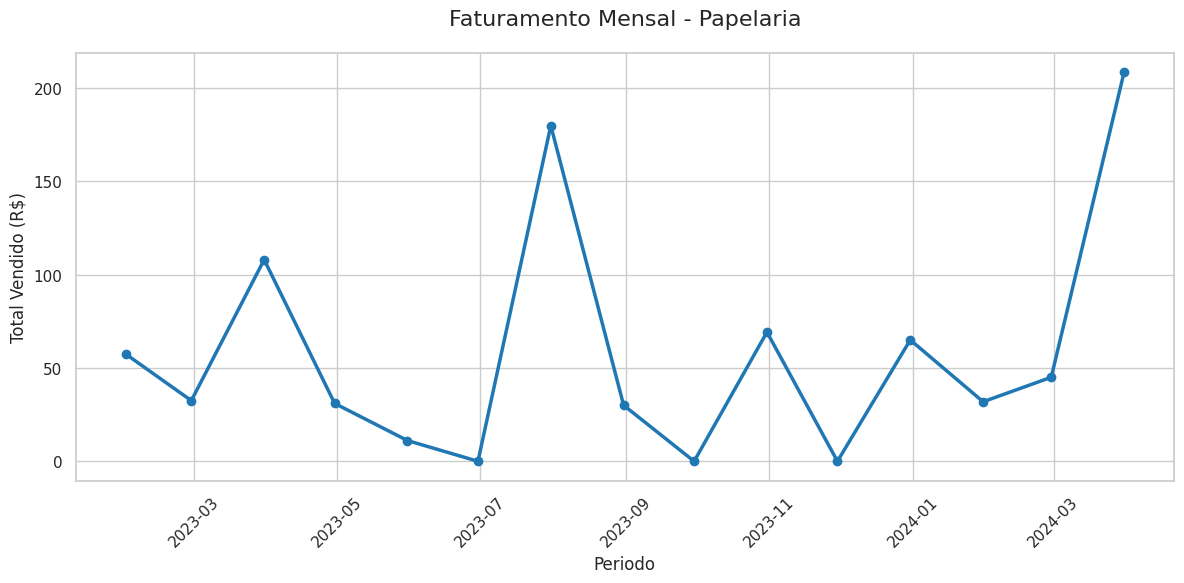

In [0]:
%python
# Gráfico de Vendas Mensais (Linha)

# Criando a figura com espaço (figsize)
plt.figure(figsize=(12, 6))

# Agrupando por mês (ME = Month End)
vendas_mensais = df_gold.resample('ME', on='data_pedido')['faturamento'].sum()

# Plotando
plt.plot(vendas_mensais.index, vendas_mensais.values, marker='o', linestyle='-', color='#1f77b4', linewidth=2.5)

# Títulos (Removi o emoji para evitar o erro de Glyph)
plt.title('Faturamento Mensal - Papelaria', fontsize=16, pad=20)
plt.xlabel('Periodo', fontsize=12)
plt.ylabel('Total Vendido (R$)', fontsize=12)

# Ajustando as datas no eixo X para não ficarem apertadas
plt.xticks(rotation=45)
plt.tight_layout() # Garante que nada fique cortado
plt.show()

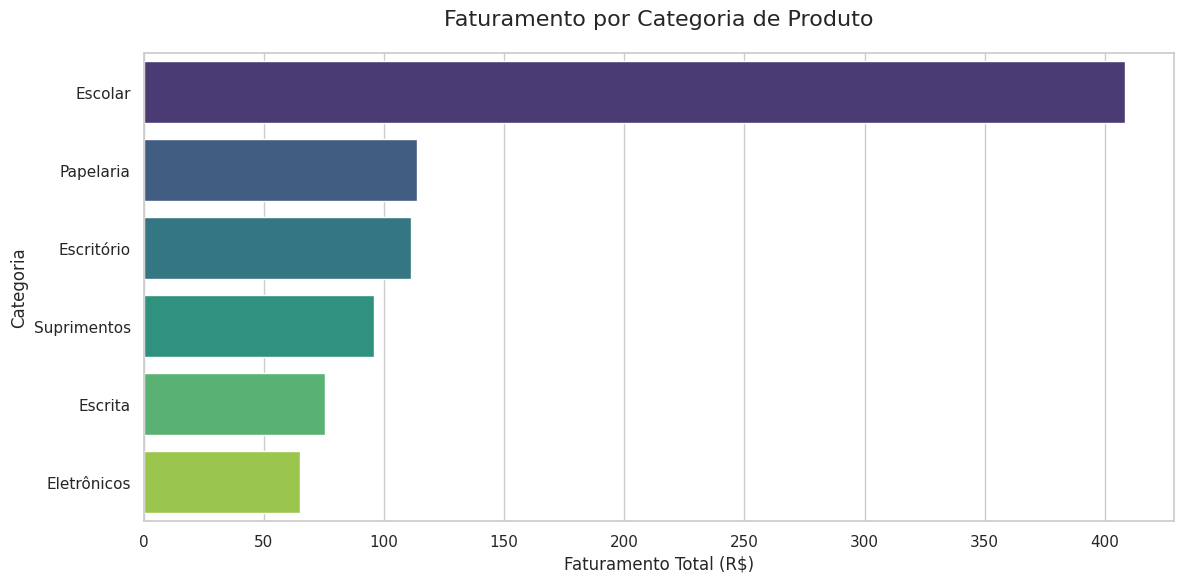

In [0]:
%python
# Gráfico de Vendas por Categoria (Barras)

plt.figure(figsize=(12, 6))

# Agrupando por categoria
vendas_cat = df_gold.groupby('categoria')['faturamento'].sum().sort_values(ascending=False)

# Usando o Seaborn para um visual mais moderno
sns.barplot(x=vendas_cat.values, y=vendas_cat.index, hue=vendas_cat.index, palette='viridis', legend=False)

plt.title('Faturamento por Categoria de Produto', fontsize=16, pad=20)
plt.xlabel('Faturamento Total (R$)', fontsize=12)
plt.ylabel('Categoria', fontsize=12)

plt.tight_layout()
plt.show()

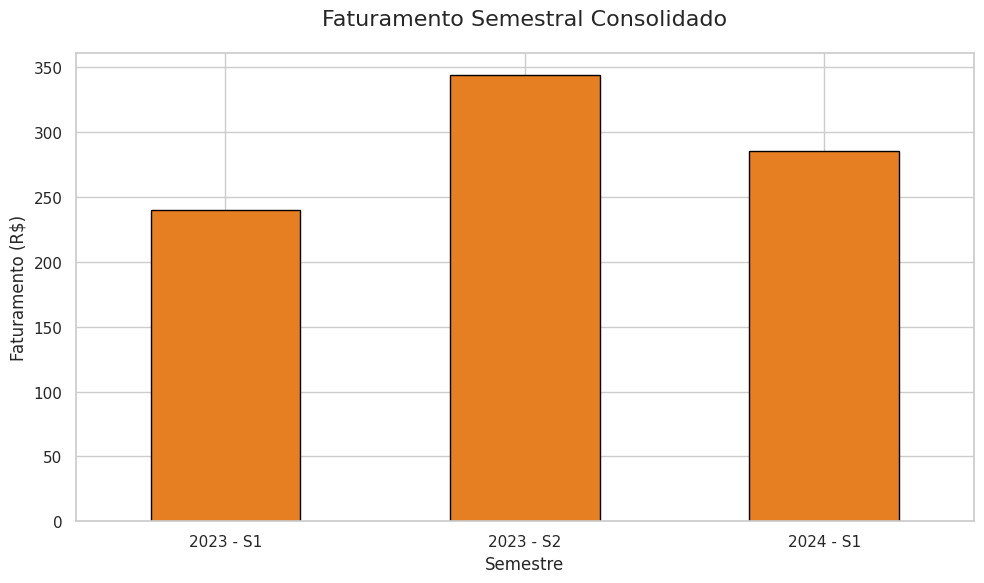

In [0]:
%python
# Gráfico Semestral (Barras)

plt.figure(figsize=(10, 6))

# Lógica para criar a coluna de Semestre
df_gold['semestre'] = df_gold['data_pedido'].dt.year.astype(str) + " - S" + \
                      np.where(df_gold['data_pedido'].dt.month <= 6, "1", "2")

vendas_semestre = df_gold.groupby('semestre')['faturamento'].sum()

vendas_semestre.plot(kind='bar', color='#e67e22', edgecolor='black')

plt.title('Faturamento Semestral Consolidado', fontsize=16, pad=20)
plt.xlabel('Semestre', fontsize=12)
plt.ylabel('Faturamento (R$)', fontsize=12)
plt.xticks(rotation=0) # Deixa o texto do eixo X reto

plt.tight_layout()
plt.show()